In [5]:
# shay dan
import pandas as pd
import seaborn as sns

assessments = pd.read_csv('assessments.csv')
courses = pd.read_csv('courses.csv')
student_assessment = pd.read_csv('studentAssessment.csv')
student_info = pd.read_csv('studentInfo.csv')
student_registration = pd.read_csv('studentRegistration.csv')
student_vle = pd.read_csv('studentVle.csv')
vle = pd.read_csv('vle.csv')

student_assessment.score = student_assessment.score.fillna(0)

In [128]:
assignments = pd.merge(student_assessment,assessments, how="inner", on="id_assessment")
assignments["weighted assignments"] = assignments["score"] * assignments["weight"] / 100
df = pd.merge(student_info,assignments, how="inner", on="id_student")
df.score = df.score.fillna(0)

<Axes: xlabel='code_module_x', ylabel='mean'>

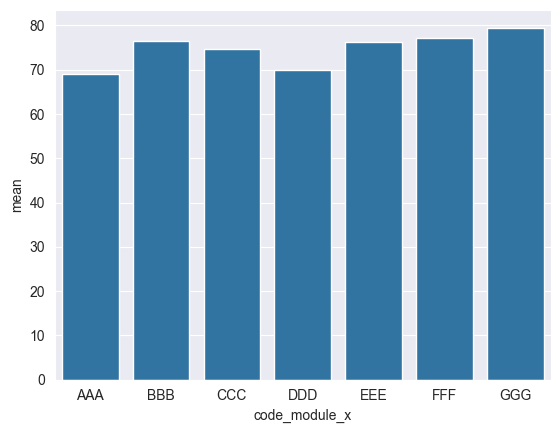

In [129]:
from matplotlib import pyplot as plt

course_averages = df.groupby(['code_module_x'])['score'].agg(['mean'])
sns.barplot(x=course_averages.index, y=course_averages['mean'])


percent of males: final_result
Distinction    0.091189
Fail           0.220923
Pass           0.370685
Withdrawn      0.317203
Name: code_module, dtype: float64
percent of females: final_result
Distinction    0.094714
Fail           0.210830
Pass           0.389659
Withdrawn      0.304797
Name: code_module, dtype: float64


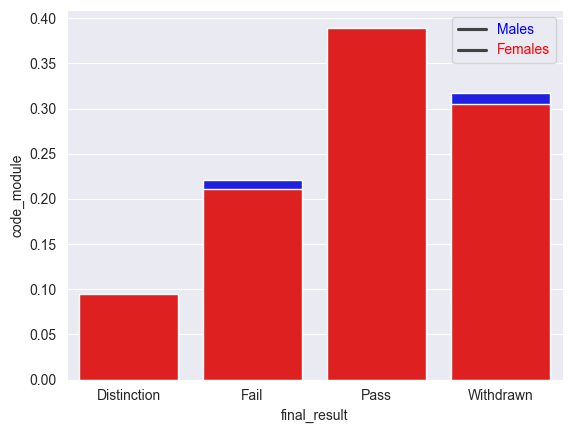

In [126]:
# who succeeds more, men or women? (rigged system)
females = student_info.groupby(['gender']).count().iloc[0].iloc[0]
males = student_info.groupby(['gender']).count().iloc[1].iloc[0]
male_success_rates = student_info.query('gender == "M"').groupby(['final_result']).count() / males
female_success_rates = student_info.query('gender == "F"').groupby(['final_result']).count() / females

sns.barplot(data=male_success_rates['code_module'], color='blue')
sns.barplot(data=female_success_rates['code_module'], color='red')
plt.legend(labels=['Males', 'Females'], labelcolor=['blue', 'red'])
print(f"percent of males: {male_success_rates.code_module}")
print(f"percent of females: {female_success_rates.code_module}")


<Axes: xlabel='final_result,imd_band'>

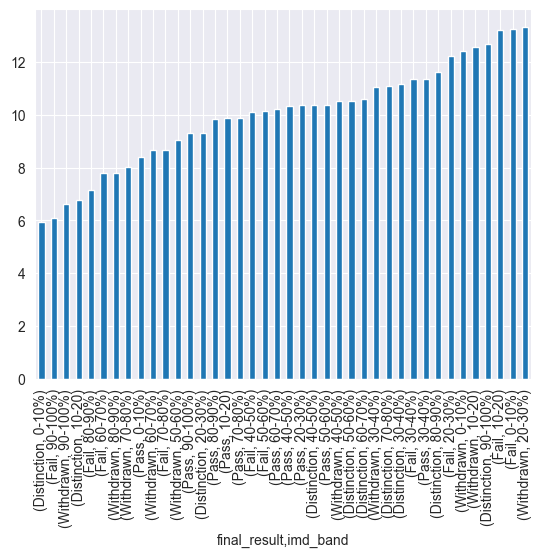

In [127]:
# what centiles are more successfull?
imd_band = student_info.groupby(['final_result', 'imd_band']).count()
imd_band = imd_band.groupby(level=0).apply(lambda x:100 * x / x.sum())
imd_band = imd_band.droplevel(0)
imd_band = imd_band['gender'].sort_values(ascending=True)
imd_band.plot(kind='bar')